In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm, linregress
import os

# Asignamos el directorio donde se encuentran los datos
data_dir = ".."

## TEMPERATURA

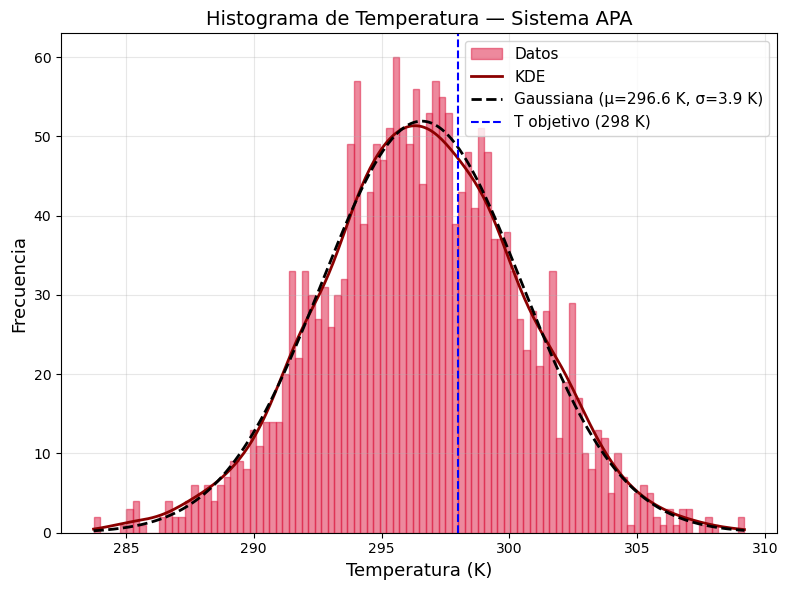

Guardado: hist_temperatura.png


In [3]:
data = []
with open(os.path.join(data_dir, "temp.xvg"), "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 2:
            data.append([float(cols[0]), float(cols[1])])

data = np.array(data)
time = data[:, 0]   # columna tiempo
T    = data[:, 1]   # columna temperatura

# Histograma
fig, ax = plt.subplots(figsize=(8, 6))

counts, bins, _ = ax.hist(T, bins=100,
                           color="crimson", alpha=0.5,
                           edgecolor="crimson", label="Datos")
kde = gaussian_kde(T)
x = np.linspace(T.min(), T.max(), 300)
scaling = len(T) * (bins[1] - bins[0])
ax.plot(x, kde(x) * scaling,
        color="darkred", linewidth=2, label="KDE")

mu, sigma = norm.fit(T)
ax.plot(x, norm.pdf(x, mu, sigma) * scaling,
        color="black", linewidth=2, linestyle="--",
        label=f"Gaussiana (μ={mu:.1f} K, σ={sigma:.1f} K)")

ax.axvline(298, color="blue", linestyle="--",
           linewidth=1.5, label="T objetivo (298 K)")

ax.set_xlabel("Temperatura (K)", fontsize=13)
ax.set_ylabel("Frecuencia", fontsize=13)
ax.set_title("Histograma de Temperatura — Sistema APA", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("hist_temperatura.png", dpi=150)
plt.show()
plt.close()
print("Guardado: hist_temperatura.png")

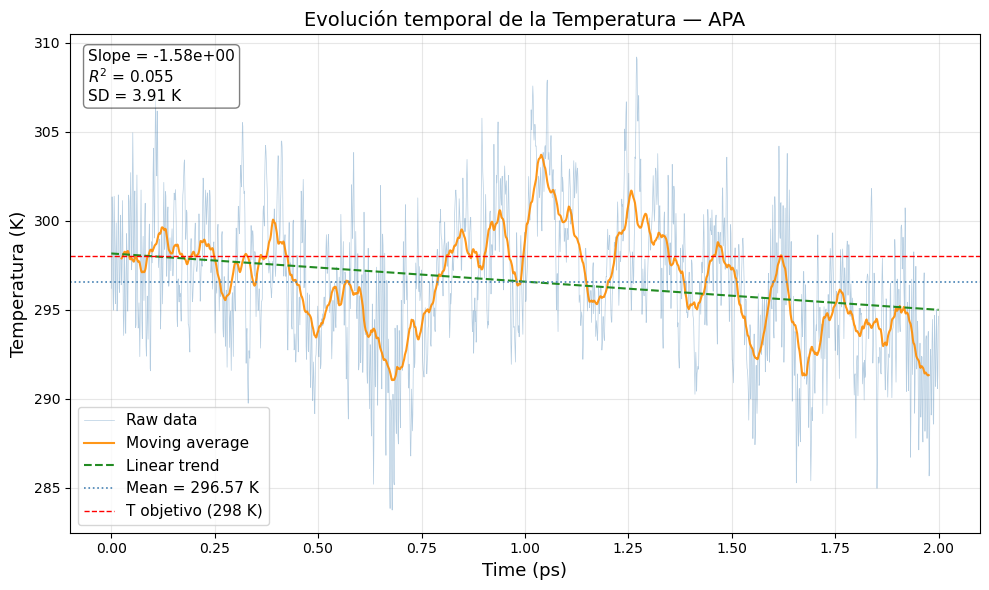

Guardado: temp_evolucion.png


In [4]:
# Evolución temporal
window = 50
ma = np.convolve(T, np.ones(window)/window, mode='valid')
time_ma = time[window//2 : window//2 + len(ma)]

slope, intercept, r, _, _ = linregress(time, T)
r2   = r**2
trend = slope * time + intercept
mean = np.mean(T)
sd   = np.std(T)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, T, color="steelblue",
        linewidth=0.5, alpha=0.4, label="Raw data")
ax.plot(time_ma, ma, color="darkorange",
        linewidth=1.5, alpha=0.9, label="Moving average")
ax.plot(time, trend, color="forestgreen", linewidth=1.5,
        linestyle="--", label="Linear trend")
ax.axhline(mean, color="steelblue", linewidth=1.2,
           linestyle=":", label=f"Mean = {mean:.2f} K")
ax.axhline(298, color="red", linewidth=1.0,
           linestyle="--", label="T objetivo (298 K)")

ax.text(0.02, 0.97,
        f"Slope = {slope:.2e}\n$R^2$ = {r2:.3f}\nSD = {sd:.2f} K",
        transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax.set_xlabel("Time (ps)", fontsize=13)
ax.set_ylabel("Temperatura (K)", fontsize=13)
ax.set_title("Evolución temporal de la Temperatura — APA", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("temp_evolucion.png", dpi=150)
plt.show()
plt.close()
print("Guardado: temp_evolucion.png")

## BOND DISTANCES

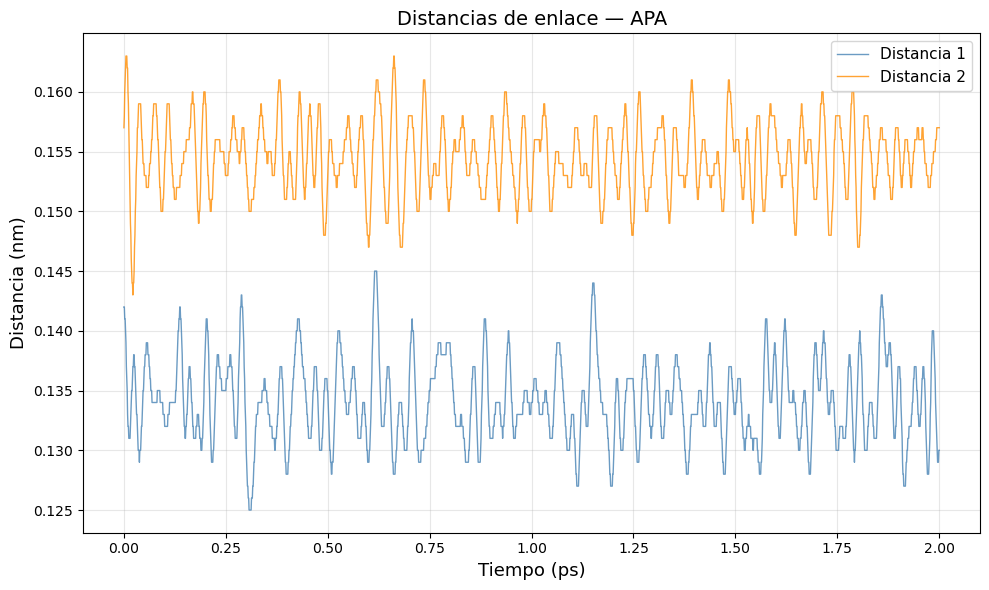

Guardado: bond_distances.png


In [5]:
# Cargamos datos (por separado)
def load_xvg(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.startswith("#") or line.startswith("@"):
                continue
            cols = line.split()
            if len(cols) >= 2:
                data.append([float(c) for c in cols])
    return np.array(data)

data1 = load_xvg(os.path.join(data_dir, "dist1.xvg"))
data2 = load_xvg(os.path.join(data_dir, "dist2.xvg"))

time      = data1[:, 0]
distance1 = data1[:, 1]
distance2 = data2[:, 1]

# Graficamos
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, distance1, color="steelblue",
        linewidth=1, alpha=0.8, label="Distancia 1")
ax.plot(time, distance2, color="darkorange",
        linewidth=1, alpha=0.8, label="Distancia 2")

ax.set_xlabel("Tiempo (ps)", fontsize=13)
ax.set_ylabel("Distancia (nm)", fontsize=13)
ax.set_title("Distancias de enlace — APA", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bond_distances.png", dpi=150)
plt.show()
plt.close()
print("Guardado: bond_distances.png")

## BOND ANGLES

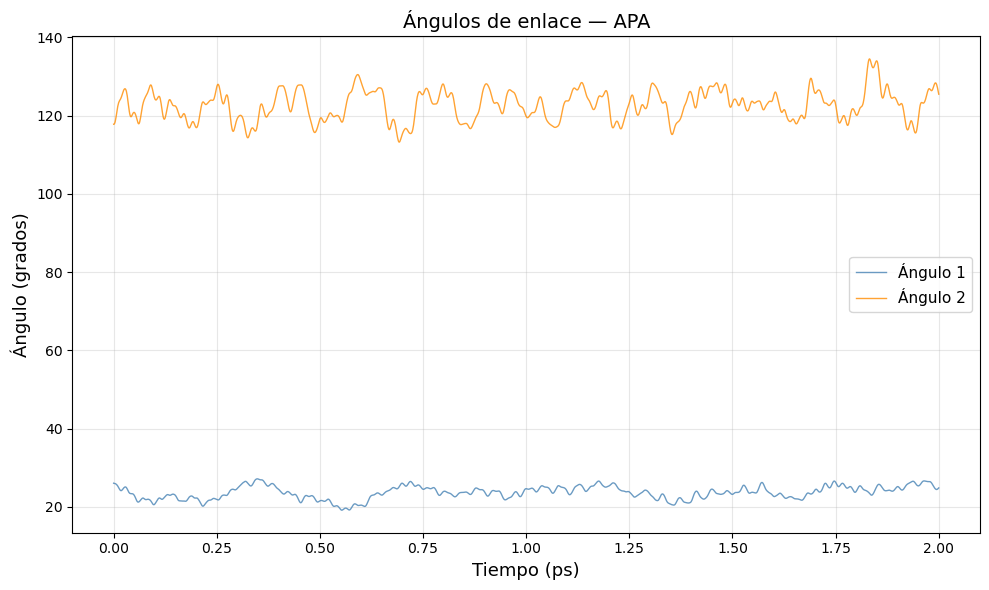

Guardado: bond_angles.png


In [11]:
# Carga de los datos (por separado)
data1 = load_xvg(os.path.join(data_dir, "angaver1.xvg"))
data2 = load_xvg(os.path.join(data_dir, "angaver2.xvg"))

time   = data1[:, 0]
angle1 = data1[:, 1]
angle2 = data2[:, 1]

# Graficamos
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, angle1, color="steelblue",
        linewidth=1, alpha=0.8, label="Ángulo 1")
ax.plot(time, angle2, color="darkorange",
        linewidth=1, alpha=0.8, label="Ángulo 2")

ax.set_xlabel("Tiempo (ps)", fontsize=13)
ax.set_ylabel("Ángulo (grados)", fontsize=13)
ax.set_title("Ángulos de enlace — APA", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bond_angles.png", dpi=150)
plt.show()
plt.close()
print("Guardado: bond_angles.png")

In [14]:
np.mean(angle1)

23.633692653673165

## DIHEDRAL ANGLES

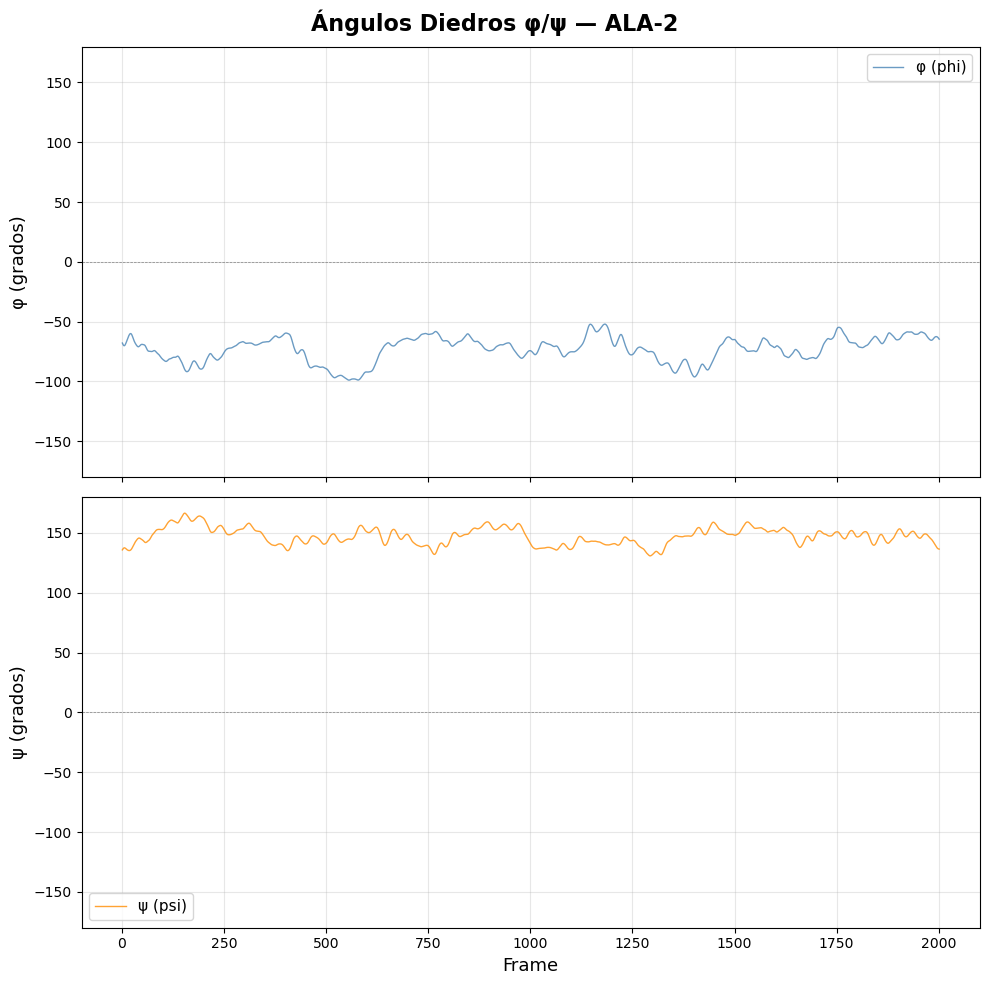

Guardado: dihedrals_ala2.png


In [6]:
# Carga de datos
data = []
with open(os.path.join(data_dir, "ala2.dat"), "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 3:
            data.append([float(c) for c in cols])

data  = np.array(data)
frame = data[:, 0]
phi   = data[:, 1]
psi   = data[:, 2]

# Graficamos
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle("Ángulos Diedros φ/ψ — ALA-2", fontsize=16, fontweight="bold") # Título

# Phi
axes[0].plot(frame, phi, color="steelblue",
             linewidth=1, alpha=0.8, label="φ (phi)")
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("φ (grados)", fontsize=13)
axes[0].set_ylim(-180, 180)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Psi
axes[1].plot(frame, psi, color="darkorange",
             linewidth=1, alpha=0.8, label="ψ (psi)")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("ψ (grados)", fontsize=13)
axes[1].set_ylim(-180, 180)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

axes[1].set_xlabel("Frame", fontsize=13)

plt.tight_layout()
plt.savefig("dihedrals_ala2.png", dpi=150)
plt.show()
plt.close()
print("Guardado: dihedrals_ala2.png")

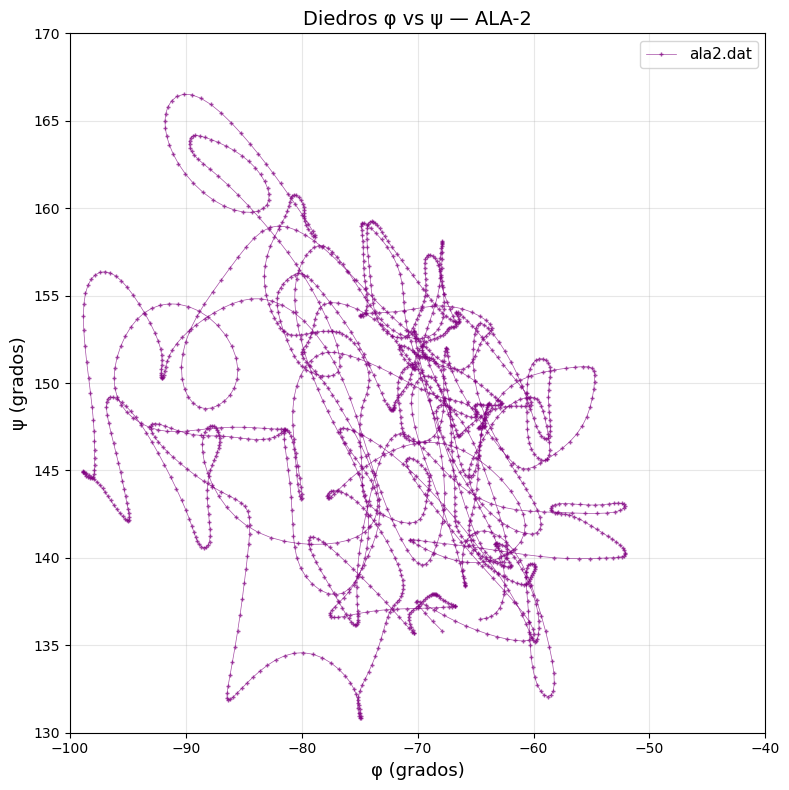

Guardado: dihedrals_phi_psi_ala2.png


In [7]:
# Gráfica con movimiento de ambos
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(phi, psi, color="purple",
        linewidth=0.5, alpha=0.7,
        marker="+", markersize=3,
        label="ala2.dat")

ax.set_xlabel("φ (grados)", fontsize=13)
ax.set_ylabel("ψ (grados)", fontsize=13)
ax.set_title("Diedros φ vs ψ — ALA-2", fontsize=14)
ax.set_xlim(-100, -40)
ax.set_ylim(130, 170)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dihedrals_phi_psi_ala2.png", dpi=150)
plt.show()
plt.close()
print("Guardado: dihedrals_phi_psi_ala2.png")

## RADIUS OF GYRATION

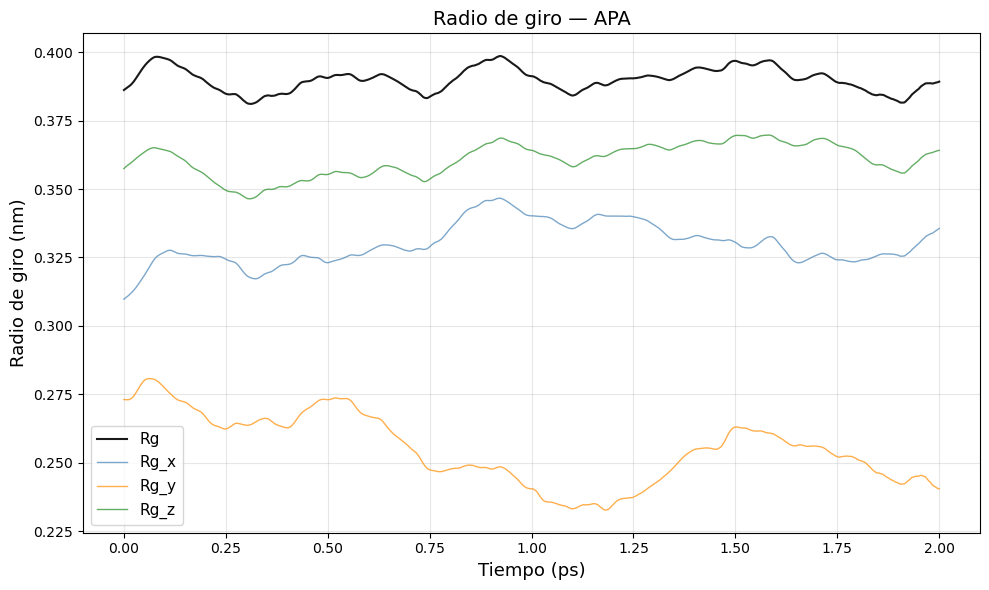

Guardado: gyration_radius.png


In [16]:
# Carga de datos
data = []
with open(os.path.join(data_dir, "gyrate.xvg"), "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 5:
            data.append([float(c) for c in cols])

data = np.array(data)
time = data[:, 0]
rg   = data[:, 1]
rg_x = data[:, 2]
rg_y = data[:, 3]
rg_z = data[:, 4]

# Graficamos
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, rg,   color="black",       linewidth=1.5, alpha=0.9, label="Rg")
ax.plot(time, rg_x, color="steelblue",   linewidth=1,   alpha=0.7, label="Rg_x")
ax.plot(time, rg_y, color="darkorange",  linewidth=1,   alpha=0.7, label="Rg_y")
ax.plot(time, rg_z, color="forestgreen", linewidth=1,   alpha=0.7, label="Rg_z")

ax.set_xlabel("Tiempo (ps)", fontsize=13)
ax.set_ylabel("Radio de giro (nm)", fontsize=13)
ax.set_title("Radio de giro — APA", fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gyration_radius.png", dpi=150)
plt.show()
plt.close()
print("Guardado: gyration_radius.png")

## Velocidad de 5 átomos distintos

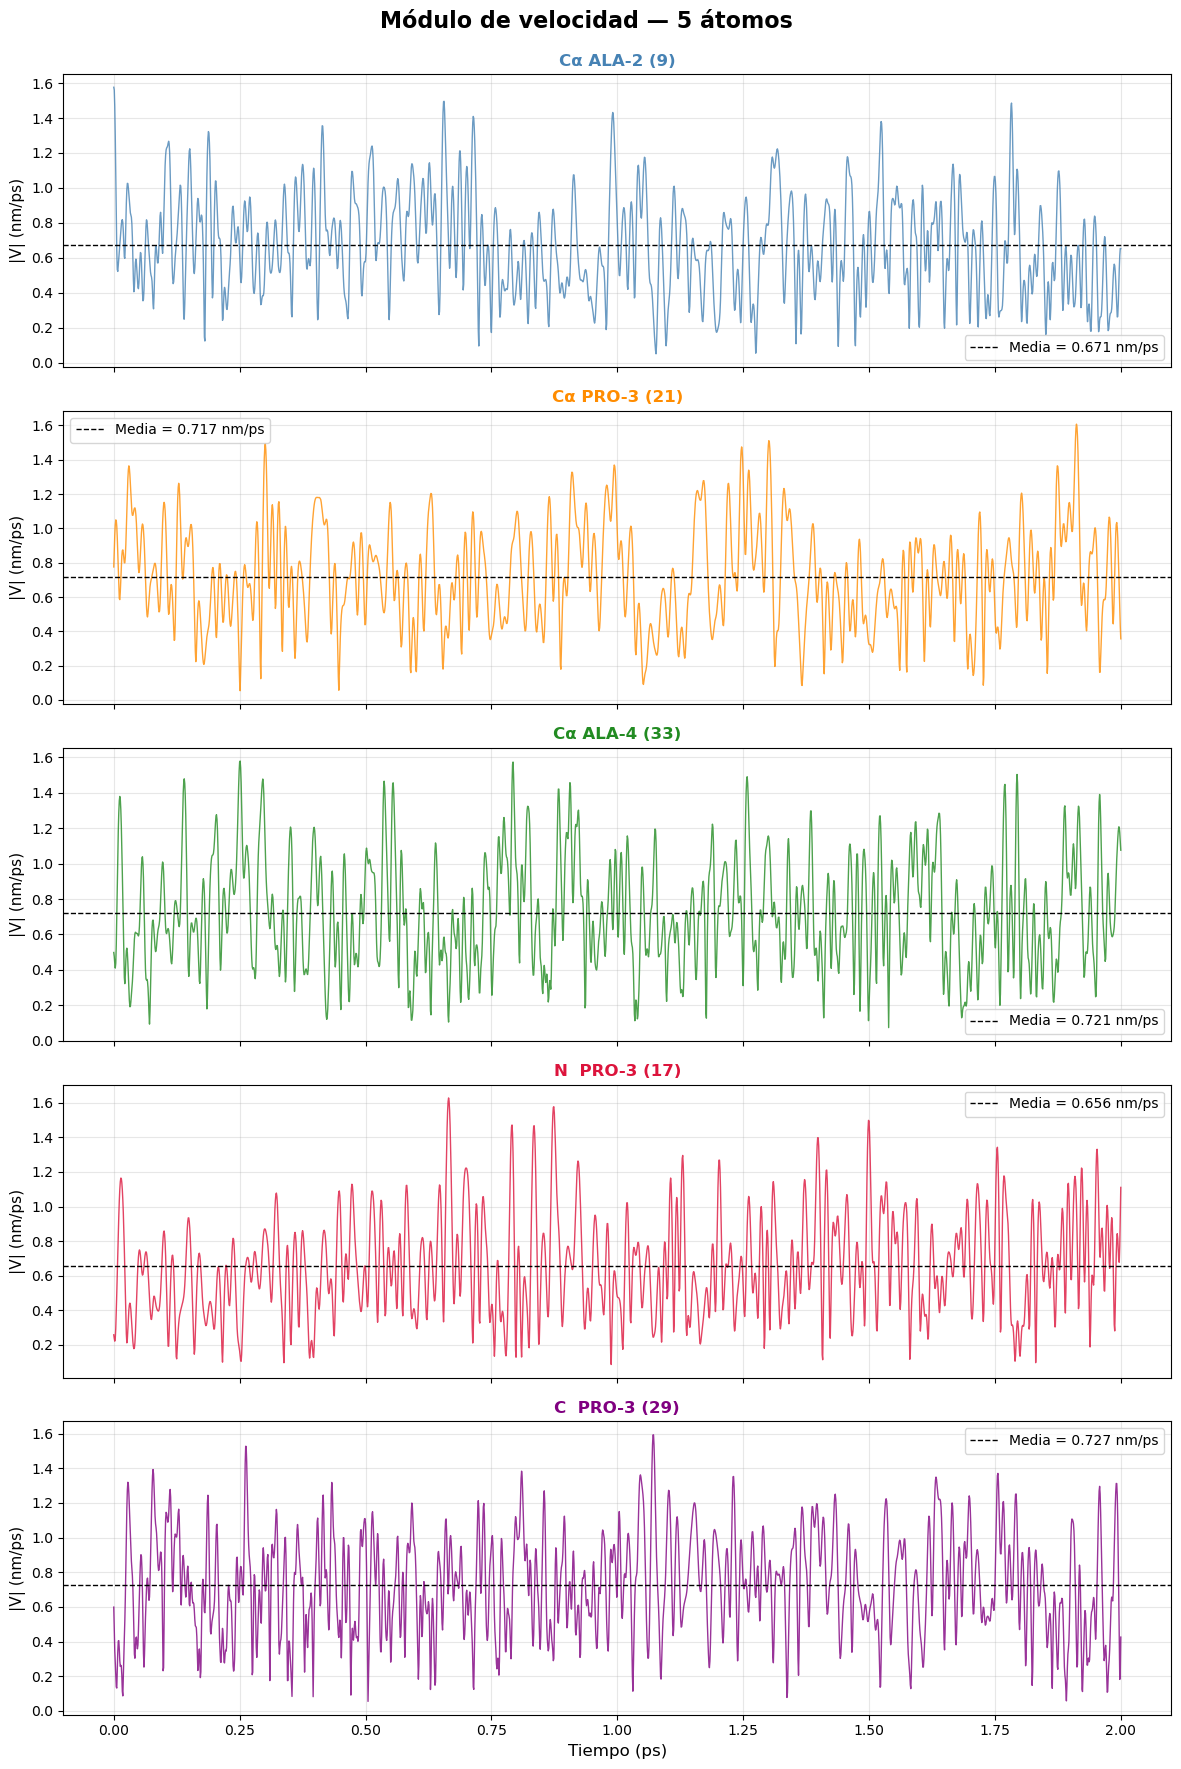

Guardado: velocities_5atoms_individual.png


In [19]:
data = []
with open(os.path.join(data_dir, "velocities_5atoms.xvg"), "r") as f:
    for line in f:
        if line.startswith("#") or line.startswith("@"):
            continue
        cols = line.split()
        if len(cols) >= 16:
            data.append([float(c) for c in cols])

data = np.array(data)
time = data[:, 0]

atoms = {
    "Cα ALA-2 (9)":  (data[:, 1:4],   "steelblue"),
    "Cα PRO-3 (21)": (data[:, 4:7],   "darkorange"),
    "Cα ALA-4 (33)": (data[:, 7:10],  "forestgreen"),
    "N  PRO-3 (17)": (data[:, 10:13], "crimson"),
    "C  PRO-3 (29)": (data[:, 13:16], "purple"),
}

# Graficamos
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
fig.suptitle("Módulo de velocidad — 5 átomos\n", fontsize=16, fontweight="bold")

for ax, (label, (vel, color)) in zip(axes, atoms.items()):
    modulo = np.sqrt(np.sum(vel**2, axis=1))
    ax.plot(time, modulo, color=color, linewidth=1, alpha=0.8)
    ax.axhline(np.mean(modulo), color="black", linewidth=1,
               linestyle="--", label=f"Media = {np.mean(modulo):.3f} nm/ps")
    ax.set_ylabel("|V| (nm/ps)", fontsize=11)
    ax.set_title(label, fontsize=12, color=color, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo (ps)", fontsize=12)

plt.tight_layout()
plt.savefig("velocities_5atoms_individual.png", dpi=150)
plt.show()
plt.close()
print("Guardado: velocities_5atoms_individual.png")

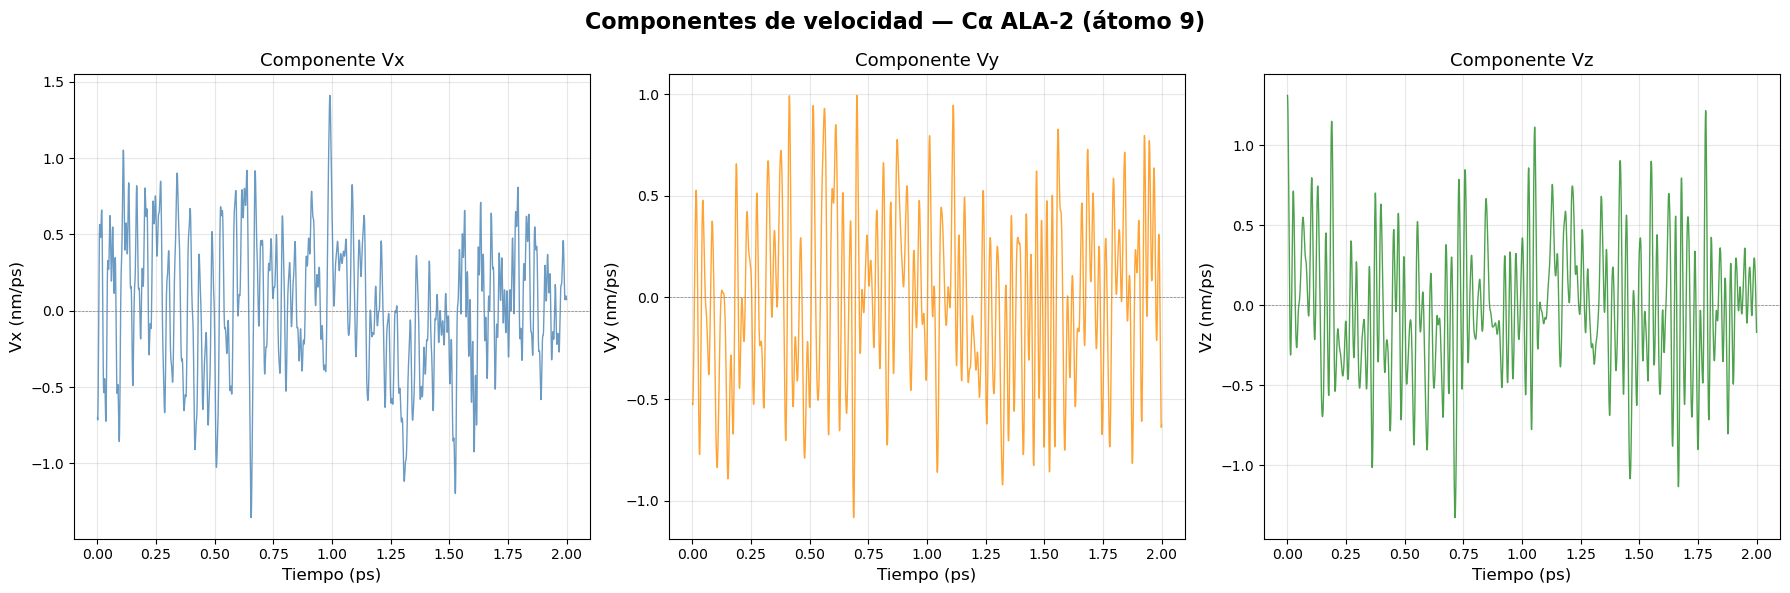

Guardado: velocities_ala2_components.png


In [10]:
# Componentes Vx, Vy, Vz del primer átomo (Cα ALA-2, índice 9)
vx = data[:, 1]
vy = data[:, 2]
vz = data[:, 3]

components = [(vx, "Vx", "steelblue"),
              (vy, "Vy", "darkorange"),
              (vz, "Vz", "forestgreen")]

# Graficamos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Componentes de velocidad — Cα ALA-2 (átomo 9)",
             fontsize=16, fontweight="bold")

for ax, (vel, label, color) in zip(axes, components):
    ax.plot(time, vel, color=color, linewidth=1, alpha=0.8)
    ax.set_xlabel("Tiempo (ps)", fontsize=12)
    ax.set_ylabel(f"{label} (nm/ps)", fontsize=12)
    ax.set_title(f"Componente {label}", fontsize=13)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("velocities_ala2_components.png", dpi=150)
plt.show()
plt.close()
print("Guardado: velocities_ala2_components.png")

## ENERGIAS

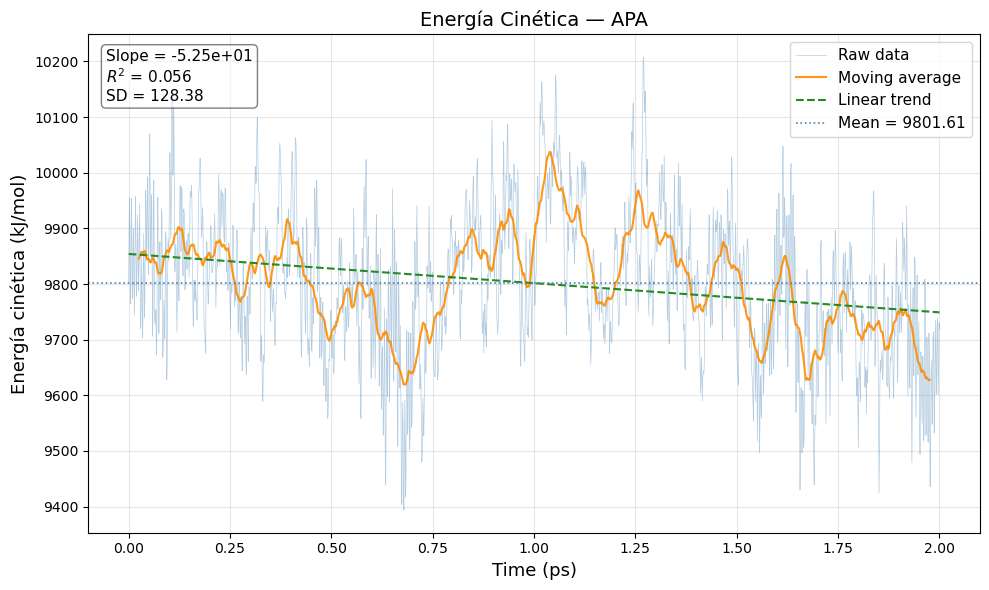

Guardado: energy_kinetic.png


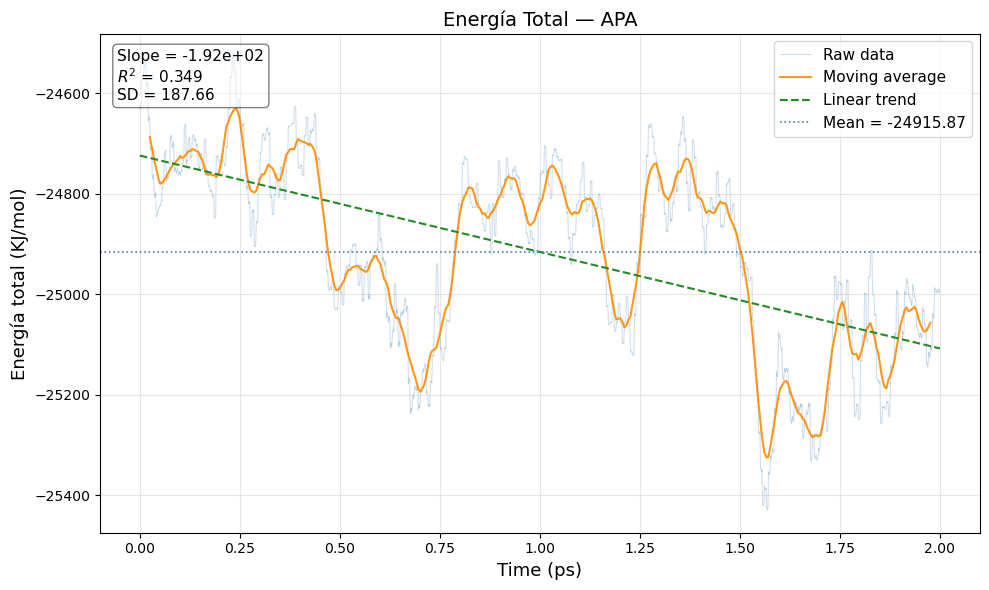

Guardado: energy_total.png


In [11]:
# Cargamos datos (por separado)
ek = load_xvg(os.path.join(data_dir, "energy_k.xvg"))
et = load_xvg(os.path.join(data_dir, "energy_t.xvg"))

# Generamos función general
def plot_energy(time, energy, title, ylabel, filename, window=50):
    # Moving average CORREGIDO
    ma = np.convolve(energy, np.ones(window)/window, mode='valid')
    time_ma = time[window//2 : window//2 + len(ma)]  # ajustar tiempo al mismo tamaño

    # Regresión lineal
    slope, intercept, r, _, _ = linregress(time, energy)
    r2 = r**2
    trend = slope * time + intercept

    # Estadísticas
    mean = np.mean(energy)
    sd   = np.std(energy)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(time, energy, color="steelblue",
            linewidth=0.5, alpha=0.4, label="Raw data")

    ax.plot(time_ma, ma, color="darkorange",
            linewidth=1.5, alpha=0.9, label="Moving average")

    ax.plot(time, trend, color="forestgreen", linewidth=1.5,
            linestyle="--", label="Linear trend")

    ax.axhline(mean, color="steelblue", linewidth=1.2,
               linestyle=":", label=f"Mean = {mean:.2f}")

    ax.text(0.02, 0.97,
            f"Slope = {slope:.2e}\n$R^2$ = {r2:.3f}\nSD = {sd:.2f}",
            transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    ax.set_xlabel("Time (ps)", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    plt.close()
    print(f"Guardado: {filename}")

# Graficamos
plot_energy(ek[:, 0], ek[:, 1],
            "Energía Cinética — APA",
            "Energía cinética (kJ/mol)",
            "energy_kinetic.png")

plot_energy(et[:, 0], et[:, 1],
            "Energía Total — APA",
            "Energía total (KJ/mol)",
            "energy_total.png")